In [ ]:
import time
import torch
import os
import IPython.display as display

if not hasattr(display, "set_matplotlib_formats"):
    # no-op fallback (or you can force retina/png instead)
    def set_matplotlib_formats(*args, **kwargs):
        return None
    display.set_matplotlib_formats = set_matplotlib_formats

from d2l.torch import Animator

from net import Net
from utils import load_val_dataset
from faco import MFACO_TSP

from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
PRETRAINED_DIR = PROJECT_ROOT / "../pretrained"

# Optional wandb logging (lazy import to avoid hangs at import-time)
USE_WANDB = True
WANDB_PROJECT = os.environ.get("WANDB_PROJECT", "claco")
WANDB_ENTITY = os.environ.get("WANDB_ENTITY") or None
WANDB_MODE = os.environ.get("WANDB_MODE", "online")  # set to "offline" to avoid network
wandb = None

def _wandb_init(config: dict, name: str | None = None):
    """Init a fresh wandb run for each train() call.

    In notebooks it's common to re-run the train cell; reusing the same wandb run
    causes non-monotonic step warnings when we log with an explicit `step=`.
    """
    global wandb, USE_WANDB
    if not USE_WANDB:
        return None
    if wandb is None:
        try:
            import wandb as _wandb
            wandb = _wandb
        except Exception as e:
            USE_WANDB = False
            print("wandb disabled (import failed):", e)
            return None
    if wandb.run is not None:
        # Start a new run to avoid step going backwards on re-runs.
        try:
            wandb.finish()
        except Exception:
            pass
    return wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        config=config,
        name=name,
        mode=WANDB_MODE,
    )

torch.manual_seed(1234)

lr = 1e-4
H=10
mini_H=100
rho = 0.5
min_new_edges = 8
disable_heuristic = False
use_local_search = True
smooth_mmas = True
extend_ls = True
normalize_heuristic = True
no_logit_net = False
no_dynamic_feats = False
k_sparse = 32
n_ants = 100
steps_per_epoch = 32
epochs = 10

device = 'cuda:0'

# Import your compiled extension (needed for get_max_threads print below)
try:
    import faco_tsp
except Exception as e:
    faco_tsp = None
    print("Warning: could not import faco_tsp:", e)

if faco_tsp is not None:
    print("faco_tsp imported. OpenMP max threads:", faco_tsp.get_max_threads())

faco_tsp imported. OpenMP max threads: 10


In [2]:
# Import training logic from train.py (keep notebook focused on experiments/plots)
from types import SimpleNamespace
import train as train_mod
from tqdm.notebook import tqdm as notebook_tqdm
from functools import partial

# Patch the tqdm symbol used inside train.py
train_mod.tqdm = partial(notebook_tqdm, disable=True)


# Re-export helpers if you still want to inspect/DEBUG them in notebook
_popcount_i64 = train_mod._popcount_i64
replay_logp_from_cpp_batch_trace = train_mod.replay_logp_from_cpp_batch_trace
train_instance = train_mod.train_instance
train_epoch_core = train_mod.train_epoch
validation_core = train_mod.validation


def _make_args(n_node, k_sparse, n_ants, steps_per_epoch, *, H, mini_H, device,
              rho=0.1, min_new_edges=8,
              disable_heuristic=True,
              use_local_search=True,
              smooth_mmas=False,
              extend_ls=False,
              normalized_heuristic=False,
              debug=False,
              use_wandb=False,
              no_logit_net=False,
              baseline='none', baseline_runs=1, baseline_time_limit=10.0):
    """Create a train.py-compatible args namespace from notebook globals."""
    return SimpleNamespace(
        # problem / graph
        n_node=int(n_node),
        k_sparse=int(k_sparse),
        n_ants=int(n_ants),
        steps_per_epoch=int(steps_per_epoch),
        epochs=None,
        lr=lr,
        seed=1234,
        device=str(device),

        # aco
        rho=float(rho),
        min_new_edges=int(min_new_edges),
        H=int(H),
        mini_H=int(mini_H),
        disable_heuristic=bool(disable_heuristic),
        no_local_search=not bool(use_local_search),
        no_smooth_mmas=not bool(smooth_mmas),
        extend_ls=bool(extend_ls),
        no_normalized_heuristic=not bool(normalized_heuristic),
        debug=bool(debug),
        no_logit_net=bool(no_logit_net),

        # logging
        no_wandb=not bool(use_wandb),
        wandb_project=WANDB_PROJECT,
        wandb_entity=WANDB_ENTITY,
        save_dir=str(PRETRAINED_DIR / 'tsp'),
        no_dynamic_feats=False,

        # baseline (validation)
        baseline=str(baseline),
        baseline_runs=int(baseline_runs),
        baseline_time_limit=float(baseline_time_limit),
    )


@torch.no_grad()
def validation(n_ants, epoch, net, val_dataset, k_sparse, animator, dynamic, args, baseline_values=None):
    """Notebook wrapper around train.py validation (keeps the old Animator plotting style)."""
    avg_last, avg_best, _gap = validation_core(
        args=args,
        epoch=epoch,
        net=net,
        val_dataset=val_dataset,
        dynamic=dynamic,
        baseline_values=baseline_values,
    )
    if animator is not None:
        animator.add(epoch + 1, (avg_last, avg_best))
    return avg_last, avg_best


def train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, dynamic,
          *,
          H=H,
          mini_H=mini_H,
          rho=rho,
          min_new_edges=min_new_edges,
          disable_heuristic=disable_heuristic,
          use_local_search=use_local_search,
          smooth_mmas=smooth_mmas,
          extend_ls=extend_ls,
          normalized_heuristic=normalize_heuristic,
          debug=False,
          use_wandb=USE_WANDB,
          no_logit_net=False,
          baseline='none',
          baseline_runs=1,
          baseline_time_limit=10.0,
          baseline_values=None,
          ):

    args = _make_args(
        n_node=n_node,
        k_sparse=k_sparse,
        n_ants=n_ants,
        steps_per_epoch=steps_per_epoch,
        H=H,
        mini_H=mini_H,
        device=device,
        rho=rho,
        min_new_edges=min_new_edges,
        disable_heuristic=disable_heuristic,
        use_local_search=use_local_search,
        smooth_mmas=smooth_mmas,
        extend_ls=extend_ls,
        normalized_heuristic=normalized_heuristic,
        debug=debug,
        use_wandb=use_wandb,
        no_logit_net=no_logit_net,
        baseline=baseline,
        baseline_runs=baseline_runs,
        baseline_time_limit=baseline_time_limit,
    )

    # (Optional) wandb init: keep the notebook helper, but make train.py see the same module
    run = None
    if use_wandb:
        run = _wandb_init(config=vars(args), name=f"tsp{n_node}")
        # make sure train.py logs to the same wandb module
        try:
            import wandb as _wb
            train_mod.wandb = _wb
            args.no_wandb = False
        except Exception as e:
            print('wandb disabled (import failed):', e)
            args.no_wandb = True

    net = Net(logit_net=not no_logit_net).to(device)
    optimizer = torch.optim.AdamW(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs, eta_min=lr * 0.1)

    val_list = load_val_dataset(n_node, device)
    animator = Animator(xlabel='epoch', xlim=[0, epochs], legend=["Avg. sample obj.", "Best ACO obj."])

    avg_last, avg_aco_best = validation(n_ants, -1, net, val_list, k_sparse, animator, dynamic, args, baseline_values=baseline_values)
    val_results = [(avg_last, avg_aco_best)]

    global_step = 0
    sum_time = 0
    best_val = float('inf')

    for epoch in range(0, epochs):
        start = time.time()
        global_step, _train_avg_cost = train_epoch_core(args, epoch, net, optimizer, global_step, dynamic=dynamic)
        scheduler.step()
        sum_time += time.time() - start

        avg_last, avg_aco_best = validation(n_ants, epoch, net, val_list, k_sparse, animator, dynamic, args, baseline_values=baseline_values)
        val_results.append((avg_last, avg_aco_best))

        if avg_aco_best < best_val:
            best_val = avg_aco_best
            os.makedirs(PRETRAINED_DIR / 'tsp', exist_ok=True)
            torch.save(net.state_dict(), f"{PRETRAINED_DIR}/tsp/tsp{n_node}.pt")

    print('total training duration:', sum_time)

    for epoch in range(-1, epochs):
        print(f'epoch {epoch}:', val_results[epoch + 1])

    if use_wandb and run is not None:
        try:
            import wandb as _wb
            _wb.finish()
        except Exception:
            pass

    # return net, val_results


Learn heuristic for TSP100: 

total training duration: 889.4103932380676
epoch -1: (8.159979201853275, 7.820822477340698)
epoch 0: (8.15211882069707, 7.820796065032482)
epoch 1: (8.133270386606455, 7.821492176502943)
epoch 2: (8.091136001050472, 7.822367742657661)
epoch 3: (8.060138538479805, 7.822977654635906)
epoch 4: (8.027133595198393, 7.821733523160219)
epoch 5: (8.004353929311037, 7.822347845882177)
epoch 6: (7.985505670309067, 7.8227841556072235)
epoch 7: (7.9757657982409, 7.823096979409456)
epoch 8: (7.967636149376631, 7.822596695274115)
epoch 9: (7.961710341274738, 7.8234994523227215)


train/avg_cost,▄▇▄▄▃▆▆▆█▅▇▆▇▂▂▆▄▄▆▆▅▄▂▇▇▅▇▅▃▃▃▄▃▃▅▁▁▂▃▄
train/best_cost,▃▃▅▅▂▂▄▇▅▂▄▅▇▃▆▂▅█▃▃▃▆▇▇▅▁▅▄▂▅▃▃▁▆▆▄▄▂▄▅
train/epoch,▁▁▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇██
train/avg_cost,8.28515
train/best_cost,8.14548
train/epoch,9


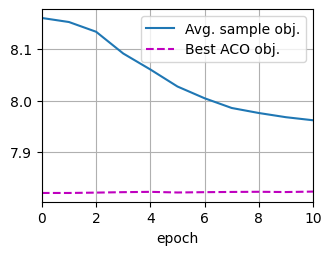

In [3]:

n_node = 100
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10

train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

Learn heuristic for TSP500: 

In [4]:

# n_node = 200
# n_ants = 100
# k_sparse = 32
# steps_per_epoch = 32
# epochs = 10
# train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

total training duration: 1000.9892234802246
epoch -1: (16.84661929309368, 16.62395814061165)
epoch 0: (16.833016350865364, 16.62558540701866)
epoch 1: (16.79435606300831, 16.624767437577248)
epoch 2: (16.78648392856121, 16.6421939432621)
epoch 3: (16.76728782057762, 16.6466533690691)
epoch 4: (16.752349987626076, 16.648564025759697)
epoch 5: (16.73502853512764, 16.65203630924225)
epoch 6: (16.716807439923286, 16.64755304157734)
epoch 7: (16.709098368883133, 16.64713767170906)
epoch 8: (16.70141838490963, 16.642510175704956)
epoch 9: (16.700617715716362, 16.643491983413696)


train/avg_cost,▅▆▆▇▆█▅▆▇▄▆▇▅█▄▆▆▅█▅█▅▅▅█▅▅▇▅▆▁▄▆▆▅▅▃▄▃▅
train/best_cost,▄▄▅▅▆▅▅▄▆▄▅▃▄▅▆▇▃▇▆▂▆█▅▄▆▅▅▁▄▄▃▅▃▆▅▅▄▅▄▂
train/epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇████
train/avg_cost,16.48189
train/best_cost,16.42596
train/epoch,9


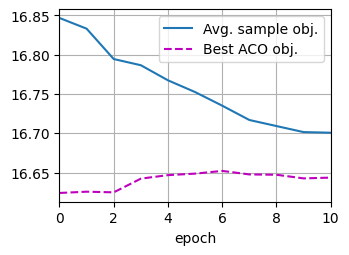

In [5]:
n_node = 500
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

total training duration: 1087.064305305481
epoch -1: (23.500972986221313, 23.32793939113617)
epoch 0: (23.476054549217224, 23.344552636146545)
epoch 1: (23.461919903755188, 23.35355532169342)
epoch 2: (23.42408311367035, 23.327942490577698)
epoch 3: (23.41507363319397, 23.34075152873993)
epoch 4: (23.39922869205475, 23.340043544769287)
epoch 5: (23.415589570999146, 23.36675226688385)
epoch 6: (23.422221660614014, 23.37928605079651)
epoch 7: (23.437485933303833, 23.39714026451111)
epoch 8: (23.43748128414154, 23.399020314216614)
epoch 9: (23.42354118824005, 23.386043787002563)


train/avg_cost,▂▂▆▃▆▃▅▄▅▄▂▁▃▃▄▄▁▃▅▂▃▄▆▅▅▄▆▃▂▂▄▃▃▄█▃▄▆▄▄
train/best_cost,▂▅▂▂▅▄▂▃▅▅▄▂▂▃▄▂▆▄▆▄▄▄▅█▃▆▄▃▃▄▅▄▂▁▃▄▅▅▅▅
train/epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇█████
train/avg_cost,23.21894
train/best_cost,23.17853
train/epoch,9


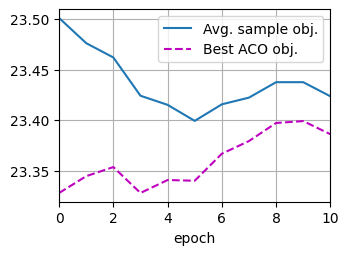

In [6]:
n_node = 1000
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

In [7]:
# n_nod  , k_sparse, n_ants, steps_per_epoch, epochs, True)

total training duration: 2133.486936569214
epoch -1: (51.66691875457764, 51.58771753311157)
epoch 0: (51.662946701049805, 51.60898780822754)
epoch 1: (51.677781105041504, 51.633551359176636)
epoch 2: (51.69669795036316, 51.664313554763794)
epoch 3: (51.71710777282715, 51.69176983833313)
epoch 4: (51.70607137680054, 51.68672561645508)
epoch 5: (51.773205280303955, 51.756078481674194)
epoch 6: (51.76131534576416, 51.74476099014282)
epoch 7: (51.74918818473816, 51.733206272125244)
epoch 8: (51.80531454086304, 51.789979457855225)
epoch 9: (51.77196741104126, 51.756558656692505)


train/avg_cost,▅▅▃▁█▆▁▇▆▂▂▅▃▄▄▅▆▄▆▃▂▁█▁▄▆▁▇▆▄▆▄▆█▆▆▅▃██
train/best_cost,▁▄▄▅▅▃▅▄▄▃▃▆▃▄▃▄▅▃▅▅▄▅▅▅▆▅▆▅▆▄▅▅█▄▅▃▄▅▅▅
train/epoch,▁▁▁▁▁▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██
train/avg_cost,51.72491
train/best_cost,51.70831
train/epoch,9


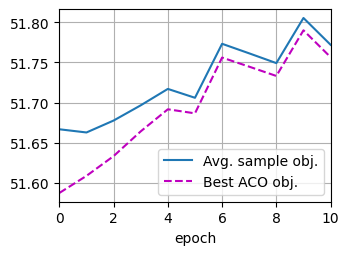

In [8]:
n_node = 5000
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)